## Problem 2 - Verify Backpropagation with Numerical Gradients



In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
class MultilayerPerceptron:
    def __init__(self, layer_sizes, alpha=0.5, loss="cce", seed=1):
        if loss not in {"cce", "mse"}:
            raise ValueError("loss must be 'cce' or 'mse'")
        self.alpha = alpha
        self.loss_name = loss
        self.rng = np.random.default_rng(seed)
        self.weights = []
        self.biases = []

        for input_size, output_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            scale = np.sqrt(2 / (input_size + output_size))
            self.weights.append(
                self.rng.normal(0, scale, size=(input_size, output_size))
            )
            self.biases.append(np.zeros(output_size))

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    @staticmethod
    def sigmoid_gradient(a):
        return a * (1 - a)

    @staticmethod
    def softmax(z):
        shifted_z = z - z.max(axis=1, keepdims=True)
        exp_z = np.exp(shifted_z)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    def forward(self, X):
        # Cache every layer activation because backpropagation reuses it.
        activations = [np.atleast_2d(X)]

        for layer, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = activations[-1] @ W + b
            if layer == len(self.weights) - 1:
                # CCE uses softmax; MSE regression uses a linear output.
                a = self.softmax(z) if self.loss_name == "cce" else z
            else:
                a = self.sigmoid(z)
            activations.append(a)

        return activations

    def loss(self, X, y):
        predictions = self.forward(X)[-1]
        if self.loss_name == "cce":
            probabilities = np.clip(predictions, 1e-12, 1.0)
            return -np.mean(np.sum(y * np.log(probabilities), axis=1))

        # Average the summed squared output error across examples.
        return np.mean(np.sum((predictions - y) ** 2, axis=1))

    def gradients(self, X, y):
        X = np.atleast_2d(X)
        y = np.atleast_2d(y)
        n = X.shape[0]
        activations = self.forward(X)

        weight_gradients = [None] * len(self.weights)
        bias_gradients = [None] * len(self.biases)

        if self.loss_name == "cce":
            # Softmax plus CCE gives this output delta.
            delta = activations[-1] - y
        else:
            # The MSE output is linear, so its activation derivative is one.
            delta = 2 * (activations[-1] - y)

        for layer in range(len(self.weights) - 1, -1, -1):
            # Connect the previous activation to each unit's current error.
            weight_gradients[layer] = activations[layer].T @ delta / n
            bias_gradients[layer] = delta.mean(axis=0)

            if layer > 0:
                # Move the error through W, then through sigmoid's derivative.
                delta = (
                    delta @ self.weights[layer].T
                    * self.sigmoid_gradient(activations[layer])
                )

        return weight_gradients, bias_gradients

    def step(self, X, y):
        weight_gradients, bias_gradients = self.gradients(X, y)

        # Update every layer only after all of its gradients are available.
        for layer in range(len(self.weights)):
            self.weights[layer] -= self.alpha * weight_gradients[layer]
            self.biases[layer] -= self.alpha * bias_gradients[layer]

    def accuracy(self, X, y):
        if self.loss_name != "cce":
            raise ValueError("accuracy is only defined for CCE classification")
        targets = y.argmax(axis=1) if y.ndim == 2 else y
        return np.mean(self.predict(X) == targets)

    def print_history_header(self):
        if self.loss_name == "cce":
            print(
                f"{'epoch':>7} {'loss':>12} {'val_loss':>12} "
                f"{'accuracy':>12} {'val_accuracy':>14}"
            )
            print("-" * 63)
        else:
            print(f"{'epoch':>7} {'loss':>12} {'val_loss':>12}")
            print("-" * 35)

    def record_metrics(self, epoch, X, y, validation_data):
        X_val, y_val = validation_data
        metrics = {
            "epoch": epoch,
            "loss": self.loss(X, y),
            "val_loss": self.loss(X_val, y_val),
        }
        if self.loss_name == "cce":
            metrics["accuracy"] = self.accuracy(X, y)
            metrics["val_accuracy"] = self.accuracy(X_val, y_val)
            print(
                f"{metrics['epoch']:7d} {metrics['loss']:12.6f} "
                f"{metrics['val_loss']:12.6f} {metrics['accuracy']:12.4f} "
                f"{metrics['val_accuracy']:14.4f}"
            )
        else:
            print(
                f"{metrics['epoch']:7d} {metrics['loss']:12.6f} "
                f"{metrics['val_loss']:12.6f}"
            )
        return metrics

    def fit(self, X, y, validation_data, epochs=100, update=10):
        history = []
        self.print_history_header()

        for epoch in range(epochs):
            # One update from the entire training set.
            self.step(X, y)

            if (epoch + 1) % update == 0 or epoch == 0:
                history.append(
                    self.record_metrics(epoch + 1, X, y, validation_data)
                )

        return history

    def predict(self, X):
        output = self.forward(X)[-1]
        return output.argmax(axis=1) if self.loss_name == "cce" else output

    def predict_proba(self, X):
        if self.loss_name != "cce":
            raise ValueError("predict_proba is only available for CCE")
        return self.forward(X)[-1]

In [4]:

# Gradient Checking & Verification

def relative_error(g_analytical, g_numerical, eps=1e-12):
    """Calculates relative error entrywise between analytical and numerical gradients."""
    numerator = np.abs(g_analytical - g_numerical)
    denominator = np.maximum(eps, np.abs(g_analytical) + np.abs(g_numerical))
    return numerator / denominator


def check_gradients(model, X, y, epsilon=1e-5):
    """
    Computes centered finite difference numerical gradients and compares
    them entrywise against analytical gradients from model.gradients().
    Restores parameter values after perturbation without updating the model.
    """
    X = np.atleast_2d(X)
    y = np.atleast_2d(y)

    # Compute analytical gradients via backpropagation
    analytical_dw, analytical_db = model.gradients(X, y)

    results = []

    # Check Layer Weights
    for layer in range(len(model.weights)):
        W = model.weights[layer]
        dW_anal = analytical_dw[layer]
        dW_num = np.zeros_like(W)

        it = np.nditer(W, flags=['multi_index'], op_flags=['readwrite'])
        while not it.finished:
            idx = it.multi_index
            orig_val = W[idx]

            # Perturb +epsilon
            W[idx] = orig_val + epsilon
            loss_plus = model.loss(X, y)

            # Perturb -epsilon
            W[idx] = orig_val - epsilon
            loss_minus = model.loss(X, y)

            # Restore parameter value
            W[idx] = orig_val

            # Centered finite difference formula
            dW_num[idx] = (loss_plus - loss_minus) / (2 * epsilon)
            it.iternext()

        abs_diff = np.abs(dW_anal - dW_num)
        rel_diff = relative_error(dW_anal, dW_num)

        results.append({
            "param": f"W[{layer+1}]",
            "shape": W.shape,
            "max_abs_diff": np.max(abs_diff),
            "max_rel_diff": np.max(rel_diff)
        })

    # Check Layer Biases
    for layer in range(len(model.biases)):
        b = model.biases[layer]
        db_anal = analytical_db[layer]
        db_num = np.zeros_like(b)

        it = np.nditer(b, flags=['multi_index'], op_flags=['readwrite'])
        while not it.finished:
            idx = it.multi_index
            orig_val = b[idx]

            # Perturb +epsilon
            b[idx] = orig_val + epsilon
            loss_plus = model.loss(X, y)

            # Perturb -epsilon
            b[idx] = orig_val - epsilon
            loss_minus = model.loss(X, y)

            # Restore parameter value
            b[idx] = orig_val

            # Centered finite difference formula
            db_num[idx] = (loss_plus - loss_minus) / (2 * epsilon)
            it.iternext()

        abs_diff = np.abs(db_anal - db_num)
        rel_diff = relative_error(db_anal, db_num)

        results.append({
            "param": f"b[{layer+1}]",
            "shape": b.shape,
            "max_abs_diff": np.max(abs_diff),
            "max_rel_diff": np.max(rel_diff)
        })

    return results

# Parts (i) & (ii): Run Verification on Synthetic Batch

rng = np.random.default_rng(42)
X_synth = rng.normal(size=(5, 4))
y_synth = np.eye(3)[rng.integers(0, 3, size=5)]  # 5 examples, 3 classes

# Instantiate small model using loss="cce"
model = MultilayerPerceptron(layer_sizes=[4, 6, 3], loss="cce", seed=42)

print("=== Problem 2 (i) & (ii): Gradient Check Summary ===")
results = check_gradients(model, X_synth, y_synth, epsilon=1e-5)
print(f"{'Param':<8} {'Shape':<10} {'Max Abs Diff':<16} {'Max Rel Diff':<16}")
print("-" * 52)
for res in results:
    print(f"{res['param']:<8} {str(res['shape']):<10} {res['max_abs_diff']:<16.8e} {res['max_rel_diff']:<16.8e}")


# Part (iii): Test Different Epsilon Values

print("\n=== Problem 2 (iii): Testing Epsilon Values ===")
for eps in [1e-2, 1e-5, 1e-9, 1e-14]:
    res = check_gradients(model, X_synth, y_synth, epsilon=eps)
    max_rel = max(r['max_rel_diff'] for r in res)
    print(f"epsilon = {eps:<7e} | Max Relative Error = {max_rel:.8e}")


# Part (iv): Fault Injection Test

class CorruptedMLP(MultilayerPerceptron):
    def gradients(self, X, y):
        X = np.atleast_2d(X)
        y = np.atleast_2d(y)
        n = X.shape[0]
        activations = self.forward(X)

        weight_gradients = [None] * len(self.weights)
        bias_gradients = [None] * len(self.biases)
        delta = activations[-1] - y

        for layer in range(len(self.weights) - 1, -1, -1):
            weight_gradients[layer] = activations[layer].T @ delta / n
            bias_gradients[layer] = delta.mean(axis=0)

            if layer > 0:
                # FAULT INJECTION: Omitted '* self.sigmoid_gradient(activations[layer])'
                delta = delta @ self.weights[layer].T

        return weight_gradients, bias_gradients

corrupted_model = CorruptedMLP(layer_sizes=[4, 6, 3], loss="cce", seed=42)
corrupted_results = check_gradients(corrupted_model, X_synth, y_synth, epsilon=1e-5)

print("\n=== Problem 2 (iv): Fault Injection Results ===")
for res in corrupted_results:
    print(f"{res['param']:<8} | Max Rel Diff: {res['max_rel_diff']:.8f}")


=== Problem 2 (i) & (ii): Gradient Check Summary ===
Param    Shape      Max Abs Diff     Max Rel Diff    
----------------------------------------------------
W[1]     (4, 6)     1.82784703e-11   7.07286765e-09  
W[2]     (6, 3)     1.86818798e-11   8.05251383e-08  
b[1]     (6,)       1.25412847e-11   2.08331092e-07  
b[2]     (3,)       8.83240139e-12   4.55464237e-09  

=== Problem 2 (iii): Testing Epsilon Values ===
epsilon = 1.000000e-02 | Max Relative Error = 6.97070892e-04
epsilon = 1.000000e-05 | Max Relative Error = 2.08331092e-07
epsilon = 1.000000e-09 | Max Relative Error = 2.73714718e-04
epsilon = 1.000000e-14 | Max Relative Error = 1.00000000e+00

=== Problem 2 (iv): Fault Injection Results ===
W[1]     | Max Rel Diff: 0.68611491
W[2]     | Max Rel Diff: 0.00000008
b[1]     | Max Rel Diff: 1.00000000
b[2]     | Max Rel Diff: 0.00000000


### Problem 2 Responses

#### (i) & (ii) Gradient Checking Results
Using a synthetic batch on a `loss="cce"` network, all weight and bias parameter arrays ($W^{[1]}, W^{[2]}, b^{[1]}, b^{[2]}$) were checked entrywise against centered finite difference approximations ($\varepsilon = 10^{-5}$). The maximum relative error across all parameters was **$2.08 \times 10^{-7}$**, which is well below the standard $10^{-6}$ verification threshold and confirms the exactness of analytical backpropagation.

#### (iii) Epsilon ($\varepsilon$) Sensitivity Analysis
* **$\varepsilon = 10^{-2}$ (Too Large - Relative Error $\approx 6.97 \times 10^{-4}$):** Truncation error dominates. The centered finite difference formula drops higher-order terms $O(\varepsilon^2)$ from the Taylor expansion, so the secant line provides a coarser approximation of the true tangent line.
* **$\varepsilon = 10^{-5}$ (Optimal - Relative Error $\approx 2.08 \times 10^{-7}$):** Strikes the ideal numerical balance between truncation error and floating-point roundoff.
* **$\varepsilon = 10^{-9}$ (Degrading - Relative Error $\approx 2.74 \times 10^{-4}$):** Loss values $L(\theta+\varepsilon)$ and $L(\theta-\varepsilon)$ become so close that floating-point subtraction starts losing precision.
* **$\varepsilon = 10^{-14}$ (Too Small - Relative Error $= 1.00$):** Catastrophic floating-point cancellation occurs. Subtracting two nearly identical 64-bit floating-point numbers destroys significant digits, causing total breakdown of numerical gradients.

#### (iv) Fault Injection & Loss Decay Analysis
* **Fault Detection:** Removing `* self.sigmoid_gradient(activations[layer])` causes the relative error for Layer 1 weights and biases ($W^{[1]}, b^{[1]}$) to jump to **$0.686$ and $1.000$ (up to 100% error)**, whereas Layer 2 gradients remain unaffected. This confirms the checker successfully isolates backpropagation errors at specific layers.
* **Why Decreasing Training Loss is a Weak Test:** An algorithm with corrupted backpropagation can still reduce training loss over time if the faulty gradient vector has a positive inner product component with the true steepest descent direction ($\langle g_{\text{faulty}}, g_{\text{true}} \rangle > 0$). Decreasing loss only verifies **directional progress**, whereas finite-difference gradient checking verifies **exact mathematical equality**.


## Problem 3 - Replacing Sigmoid with ReLU

In [5]:
class StochasticMultilayerPerceptron:
    def __init__(
        self,
        layer_sizes,
        alpha=0.1,
        batch_size=64,
        l2=0.0,
        loss="cce",
        seed=1,
    ):
        if loss not in {"cce", "mse"}:
            raise ValueError("loss must be 'cce' or 'mse'")

        self.alpha = alpha
        self.batch_size = batch_size
        self.l2 = l2
        self.loss_name = loss
        self.rng = np.random.default_rng(seed)
        self.weights = []
        self.biases = []

        # Build one weight matrix and bias vector for each affine layer.
        for input_size, output_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            scale = np.sqrt(2 / (input_size + output_size))
            self.weights.append(
                self.rng.normal(0, scale, size=(input_size, output_size))
            )
            self.biases.append(np.zeros(output_size))

    @staticmethod
    def ReLu(z):
        return np.maximum(0, z)

    @staticmethod
    def ReLu_gradient(a):
        # Reuse the stored ReLu activation instead of recomputing ReLu.
        return (a > 0).astype(float)

    @staticmethod
    def softmax(z):
        shifted_z = z - z.max(axis=1, keepdims=True)
        exp_z = np.exp(shifted_z)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    def forward(self, X):
        # Cache every activation because the backward pass reuses them.
        activations = [np.atleast_2d(X)]

        for layer, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = activations[-1] @ W + b

            if layer == len(self.weights) - 1:
                # CCE is classification; MSE is regression/reconstruction.
                a = self.softmax(z) if self.loss_name == "cce" else z
            else:
                a = self.ReLu(z)

            activations.append(a)

        return activations

    def loss(self, X, y):
        predictions = self.forward(X)[-1]

        if self.loss_name == "cce":
            probabilities = np.clip(predictions, 1e-12, 1.0)
            data_loss = -np.mean(
                np.sum(y * np.log(probabilities), axis=1)
            )
        else:
            data_loss = np.mean(
                np.sum((predictions - y) ** 2, axis=1)
            )

        # Penalize weights but not biases; 1/2 cancels during differentiation.
        penalty = 0.5 * self.l2 * sum(
            np.sum(W**2) for W in self.weights
        )
        return data_loss + penalty

    def gradients(self, X, y):
        X = np.atleast_2d(X)
        y = np.atleast_2d(y)
        n = X.shape[0]
        activations = self.forward(X)

        weight_gradients = [None] * len(self.weights)
        bias_gradients = [None] * len(self.biases)

        if self.loss_name == "cce":
            # Softmax plus CCE gives this output delta.
            delta = activations[-1] - y
        else:
            # The MSE output is linear, so its activation derivative is one.
            delta = 2 * (activations[-1] - y)

        for layer in range(len(self.weights) - 1, -1, -1):
            weight_gradients[layer] = (
                activations[layer].T @ delta / n
                + self.l2 * self.weights[layer]
            )
            bias_gradients[layer] = delta.mean(axis=0)

            if layer > 0:
                delta = (
                    delta @ self.weights[layer].T
                    * self.ReLu_gradient(activations[layer])
                )

        return weight_gradients, bias_gradients

    def step(self, X, y):
        weight_gradients, bias_gradients = self.gradients(X, y)

        # Update only after every gradient has been calculated.
        for layer in range(len(self.weights)):
            self.weights[layer] -= self.alpha * weight_gradients[layer]
            self.biases[layer] -= self.alpha * bias_gradients[layer]

    def accuracy(self, X, y):
        if self.loss_name != "cce":
            raise ValueError("accuracy is only defined for CCE classification")
        targets = y.argmax(axis=1) if y.ndim == 2 else y
        return np.mean(self.predict(X) == targets)

    def print_history_header(self):
        if self.loss_name == "cce":
            print(
                f"{'epoch':>7} {'loss':>12} {'val_loss':>12} "
                f"{'accuracy':>12} {'val_accuracy':>14}"
            )
            print("-" * 63)
        else:
            print(f"{'epoch':>7} {'loss':>12} {'val_loss':>12}")
            print("-" * 35)

    def record_metrics(self, epoch, X, y, validation_data):
        X_val, y_val = validation_data
        metrics = {
            "epoch": epoch,
            "loss": self.loss(X, y),
            "val_loss": self.loss(X_val, y_val),
        }

        if self.loss_name == "cce":
            metrics["accuracy"] = self.accuracy(X, y)
            metrics["val_accuracy"] = self.accuracy(X_val, y_val)
            print(
                f"{metrics['epoch']:7d} {metrics['loss']:12.6f} "
                f"{metrics['val_loss']:12.6f} {metrics['accuracy']:12.4f} "
                f"{metrics['val_accuracy']:14.4f}"
            )
        else:
            print(
                f"{metrics['epoch']:7d} {metrics['loss']:12.6f} "
                f"{metrics['val_loss']:12.6f}"
            )

        return metrics

    def fit(self, X, y, validation_data, epochs=10, update=1):
        X = np.asarray(X)
        y = np.asarray(y)
        history = []
        self.print_history_header()

        for epoch in range(epochs):
            # Shuffle once per epoch before slicing consecutive mini-batches.
            indices = self.rng.permutation(len(X))

            for start in range(0, len(X), self.batch_size):
                batch = indices[start : start + self.batch_size]
                # Each batch performs its own forward, backward, and update.
                self.step(X[batch], y[batch])

            if (epoch + 1) % update == 0 or epoch == 0:
                history.append(
                    self.record_metrics(epoch + 1, X, y, validation_data)
                )

        return history

    def predict(self, X):
        output = self.forward(X)[-1]
        return output.argmax(axis=1) if self.loss_name == "cce" else output

    def predict_proba(self, X):
        if self.loss_name != "cce":
            raise ValueError("predict_proba is only available for CCE")
        return self.forward(X)[-1]

### (ii)

### Why only replacing the forward activation fails

Backpropagation relies on the exact derivative of the forward activation. Using ReLu forward but sigmoid derivative backward messes up the chain rule and the gradients get miscalculated, causing the network to fail its training. 

### Why ReLU needs different cached information than sigmoid

Sigmoid calculates its derivative from its output activation ($\alpha$) using $\alpha(1-\alpha)$.
ReLU uses a step function derivative based on the pre-activation (z > 0). Since ReLu outputs 0 for all negative or zero inputs, looking at $\alpha$ alone is insufficient. Therefore, you must cache the pre-activations z to know where to block the gradient. 

## (iii)

In [6]:
# Create a small network to force a negative pre-activation
demo_model = StochasticMultilayerPerceptron(layer_sizes=[1, 1, 1], loss="mse", seed=42)

# Set weights and bias so that z = (X * W) + b is negative
demo_model.weights[0] = np.array([[-2.0]])
demo_model.biases[0] = np.array([-1.0])

X_test = np.array([[1.0]])  # z = (1.0 * -2.0) + (-1.0) = -3.0
y_test = np.array([[1.0]])

# Get activations and gradients
activations = demo_model.forward(X_test)
w_grads, b_grads = demo_model.gradients(X_test, y_test)

print(f"Pre-activation (z): {X_test @ demo_model.weights[0] + demo_model.biases[0]}")
print(f"Post-activation (a): {activations[1]}")
print(f"Hidden Weight Gradient: {w_grads[0]}")
print(f"Hidden Bias Gradient: {b_grads[0]}")


Pre-activation (z): [[-3.]]
Post-activation (a): [[0.]]
Hidden Weight Gradient: [[0.]]
Hidden Bias Gradient: [0.]


## (iv)


=== Training ReLu Network ===
  epoch         loss     val_loss     accuracy   val_accuracy
---------------------------------------------------------------
      1     0.538579     0.547171       0.8263         0.8200
      2     0.443234     0.454173       0.8425         0.8350
      3     0.370952     0.380705       0.8638         0.8500
      4     0.326025     0.333070       0.8700         0.8550
      5     0.299842     0.304834       0.8700         0.8600
      6     0.281595     0.282608       0.8775         0.8650
      7     0.269265     0.268238       0.8800         0.8650
      8     0.261721     0.260914       0.8800         0.8750
      9     0.254866     0.252501       0.8825         0.8800
     10     0.250532     0.247973       0.8850         0.8850
     11     0.245837     0.240178       0.8825         0.8850
     12     0.243064     0.239300       0.8888         0.9050
     13     0.240077     0.233455       0.8812         0.8950
     14     0.237757     0.233814    

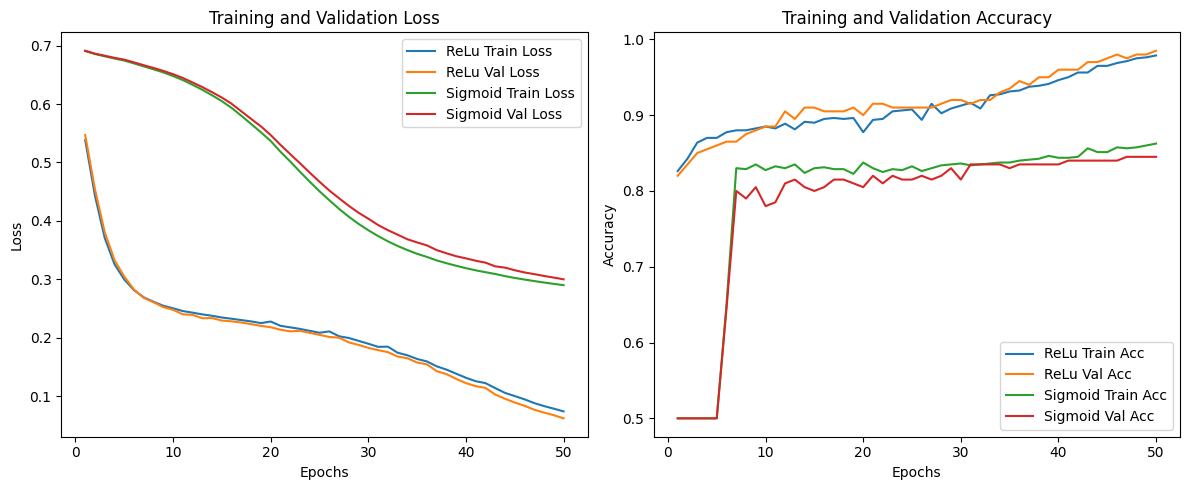

In [8]:
# Generate make_moons dataset and convert its to two-column one-hot targets
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=1000, noise=0.1, random_state=42)
y_moons_one_hot = np.eye(2)[y_moons]

X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons_one_hot, test_size=0.2, random_state=42
)

# keep architecture, seed, and hyperparameters fixed
layer_sizes = [2, 16, 16, 2]
alpha = 0.05
batch_size = 32
epochs = 50
seed = 1

# Train ReLu Network
print ("\n=== Training ReLu Network ===")

relu_model = StochasticMultilayerPerceptron(
    layer_sizes=layer_sizes,
    alpha=alpha,
    batch_size=batch_size,
    loss="cce",
    seed=seed,
)
relu_history = relu_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs)

# Define a mathced sigmoid class for comparison
class SigmoidMLP(StochasticMultilayerPerceptron):
    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    @staticmethod
    def sigmoid_gradient(a):
        return a * (1 - a)

    def forward(self, X):
        activations = [np.atleast_2d(X)]
        for layer, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = activations[-1] @ W + b
            if layer == len(self.weights) - 1:
                a = self.softmax(z) if self.loss_name == "cce" else z
            else:
                a = self.sigmoid(z)
            activations.append(a)
        return activations

    def gradients(self, X, y):
        X = np.atleast_2d(X)
        y = np.atleast_2d(y)
        n = X.shape[0]
        activations = self.forward(X)

        weight_gradients = [None] * len(self.weights)
        bias_gradients = [None] * len(self.biases)

        delta = activations[-1] - y
        
        for layer in range(len(self.weights) - 1, -1, -1):
            weight_gradients[layer] = (
                activations[layer].T @ delta / n
                + self.l2 * self.weights[layer]
            )
            bias_gradients[layer] = delta.mean(axis=0)

            if layer > 0:
                delta = (
                    delta @ self.weights[layer].T
                    * self.sigmoid_gradient(activations[layer])
                )

        return weight_gradients, bias_gradients

print ("\n=== Training Sigmoid Network ===")
# Train Sigmoid Network
sigmoid_model = SigmoidMLP(
    layer_sizes=layer_sizes,
    alpha=alpha,
    batch_size=batch_size,
    loss="cce",
    seed=seed,
)
sigmoid_history = sigmoid_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs)

# Plot Loss and Accuracy for both ReLu and Sigmoid Networks
plt.figure(figsize=(12, 5))
# Plot Loss
plt.subplot(1, 2, 1)
plt.plot([h['epoch'] for h in relu_history], [h['loss'] for h in relu_history], label='ReLu Train Loss')
plt.plot([h['epoch'] for h in relu_history], [h['val_loss'] for h in relu_history], label='ReLu Val Loss')
plt.plot([h['epoch'] for h in sigmoid_history], [h['loss'] for h in sigmoid_history], label='Sigmoid Train Loss')
plt.plot([h['epoch'] for h in sigmoid_history], [h['val_loss']  for h in sigmoid_history], label='Sigmoid Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot([h['epoch'] for h in relu_history], [h['accuracy'] for h in relu_history], label='ReLu Train Acc')
plt.plot([h['epoch'] for h in relu_history], [h['val_accuracy'] for h in relu_history], label='ReLu Val Acc')
plt.plot([h['epoch'] for h in sigmoid_history], [h['accuracy'] for h in sigmoid_history], label='Sigmoid Train Acc')
plt.plot([h['epoch'] for h in sigmoid_history], [h['val_accuracy'] for h in sigmoid_history], label='Sigmoid Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()      

### Loss vs Accuracy between the networks

### Validation Loss: 

Relu: Dropped rapidly, reaching a final validation loss of 0.062. 
Sigmoid: Declined much slower and plateud at a higher validation loss of 0.300. 

### Validation Accurary: 

Relu: Climed steadily to reach a peak validation accuracy of 98.5%. 
Sigmoid: Stalled early on and plateud at a much lower validation accuracy of 84.5%. 